In [10]:
from importlib.metadata import files as importlib_files

import numpy as np, matplotlib.pyplot as plt, scipy as sp
import matplotlib.image as mpimg
import torch
import time
import os, json
from datetime import datetime
import imageio.v3 as iio
from IPython.display import Image, display
from PIL import Image as PILImage
import shutil

pi = sp.constants.pi

# Define simulation parameters

class SimulationManager:
    def __init__(self, **kwargs):

        self.parameters = kwargs
        self.gpe = GPEBase(**self.parameters)
        self.init_type = kwargs["init_type"]; assert self.init_type == "Gaussian" or self.init_type == "Ground State", "Given init_type is invalid. Choose either Gaussian or Ground State for init_type."
        self.device = self.gpe.device
        self.rte = None
        self.ite = None

        if self.init_type == "Ground State":
            
            N, Np, omega = self.gpe.N, self.gpe.Np, self.gpe.omega
            filename=f"storage/ground_state_N_{N}_Np_{Np}_omega_{np.round(omega)}.pt".replace(".", "_")
            if os.path.exists(filename):
                print(f"Loading cached ground state from {filename}...")
                self.init_wf = torch.load(filename, map_location=self.device)

                self.gpe.visualizer = GPEVisualizer(
                    self.gpe.x, self.gpe.z, self.gpe.dx, self.gpe.dz, 
                    self.gpe.l, self.gpe.parameters, self.init_wf
                )

            else:
                print("Ground state not found. Running imaginary time evolution...")
                ite_init_wf = self.gpe.gaussian().to(self.device)
                self.gpe.visualizer = GPEVisualizer(self.gpe.x, self.gpe.z, self.gpe.dx, self.gpe.dz, self.gpe.l, self.gpe.parameters, ite_init_wf)
                self.ite = ImaginaryTimeGPE(self.gpe, ite_init_wf, **self.parameters)
                ground_state_wf = self.ite.imag_time_evolution()
                torch.save(ground_state_wf, filename)
                self.init_wf = ground_state_wf
                self.gpe.visualizer.update_initial_state(self.init_wf)


        elif self.init_type == "Gaussian":
            self.init_wf = self.gpe.gaussian().to(self.device)
            self.gpe.visualizer = GPEVisualizer(self.gpe.x, self.gpe.z, self.gpe.dx, self.gpe.dz, self.gpe.l, self.gpe.parameters, self.init_wf)

        self.gpe.init_wf = self.init_wf
        
            
    def run_simulation(self):
        # Run the simulation using the GPE engine
        self.rte = RealTimeGPE(self.gpe, self.init_wf, **self.parameters)
        final_wf = self.rte.real_time_evolution()
        return final_wf

    def export_plots(self, save_to_drive=True, download_to_local=True, IN_COLAB=True):

        os.makedirs("storage", exist_ok=True)
        self.gpe.visualizer.generate_gifs()

        # Export plots and data
        source_folder = self.gpe.visualizer.base_output_dir
        zip_name = f"{source_folder}_exported"
        safe_name = os.path.basename(zip_name)
        
        # Prepend the 'storage' directory to the archive name
        archive_base_path = os.path.join("storage", safe_name)
        
        print(f"Compressing '{source_folder}' into {archive_base_path}.zip...")
        
        # 1. Compress the folder
        # Because we added "storage/" to archive_base_path, the zip goes directly there
        shutil.make_archive(archive_base_path, 'zip', source_folder)
        
        # The exact path to the newly created zip file
        zip_filepath = f"{archive_base_path}.zip"
        
        if not IN_COLAB:
            print(f"Saved locally as {zip_filepath}. Colab features disabled.")
            return

        # Only import Colab modules if we are actually in Colab
        from google.colab import drive, files

        # 2. Copy to Google Drive
        if save_to_drive:
            print("Mounting Google Drive...")
            drive.mount('/content/drive')
            
            drive_path = f'/content/drive/MyDrive/Duke/SimulationData/{safe_name}.zip'
            
            # Copy FROM the storage folder TO Google Drive
            shutil.copy(zip_filepath, drive_path)
            print(f"Success! Copied to Google Drive at: {drive_path}")
        else:
            print("Skipping Google Drive export.")

        # 3. Trigger Local Download
        if download_to_local:
            print("Triggering local download...")
            # Download directly from the storage folder
            files.download(zip_filepath)
class GPEBase():
    def __init__(self, **kwargs):
    
        hbar = sp.constants.hbar
        pi = sp.constants.pi

        if torch.cuda.is_available():
            print(f"GPU is available: {torch.cuda.get_device_name(0)}")
        else:
            print("GPU not found. Check your runtime settings.")

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.high_precision = kwargs["high_precision"]


        self.debug = False
        self.time_plots = kwargs["time_plots"]
        self.final_plots = kwargs["final_plots"]
        self.plot_steps = kwargs["plot_steps"]



        if kwargs["high_precision"]:
            self.complex_type = torch.complex128
            self.real_type = torch.float64

        else:
            self.complex_type = torch.complex64
            self.real_type = torch.float32


        self.Np = kwargs["Np"]
        self.m = kwargs["m"]  #kg
        self.omega = kwargs["omega"] #Hz
        self.a0 = kwargs["a0"] #m
        self.g0 = 4*pi*hbar**2*self.a0* self.Np/self.m
        self.gamma = kwargs["gamma"]
        self.a02 = kwargs["a02"]
        self.g2 = 6*np.sqrt(5) * pi * hbar**2 * self.a02 * self.Np / self.m
        self.sigma = kwargs["sigma"]
        self.z_scale = kwargs["z_scale"]
        self.y_scale = kwargs["y_scale"]



        self.l = np.sqrt(hbar/(self.m * self.omega)) #length scale
        self.tau = 1/self.omega # time scale
        self.G0 = self.g0/(self.l**3*hbar*self.omega)
        self.G2 = self.g2/(hbar*self.omega*self.l**5)

        self.waist = kwargs["waist"]
        self.cutoff = kwargs["cutoff"]

        self.up = kwargs["up"]
        self.N = kwargs["N"]
        self.Nz = kwargs["Nz"] if kwargs["Nz"] is not None else kwargs["N"]

        self.ev_time = kwargs["ev_time"] #s
        self.time_steps = kwargs["time_steps"]
        self.dt = self.ev_time/self.time_steps
        self.dtau = self.dt/self.tau
        self.times = np.linspace(0, self.ev_time, self.time_steps)

        self.x = torch.linspace(-self.up,self.up,self.N+1, dtype=self.real_type)[:-1]
        self.dx = (self.x[1]-self.x[0]).item(); self.dxu = self.dx/self.l
        self.z = torch.linspace(-self.up, self.up, self.Nz+1, dtype = self.real_type)[:-1]
        self.dz = (self.z[1]-self.z[0]).item(); self.dzu = self.dz/self.l

        self.X, self.Y, self.Z = torch.meshgrid(self.x,self.x,self.z, indexing='ij')
        self.uX,self.uY, self.uZ = self.X/self.l, self.Y/self.l, self.Z/self.l

        k = 2*pi*torch.fft.fftfreq(self.N, d=self.dx/self.l,  dtype=self.real_type)
        kz = 2*pi*torch.fft.fftfreq(self.Nz, d=self.dz/self.l, dtype = self.real_type)
        self.KX, self.KY, self.KZ = torch.meshgrid(k,k,kz, indexing="ij")  # Note that spacing d, is adjusted to represent spacing in uX/Y/Z
        self.K_squared = (self.KX**2 + self.KY**2 + self.KZ**2)
        self.quadrupole_multiplier = ((1/3)*self.K_squared - self.KZ**2).to(self.device)
        self.K_squared = self.K_squared.to(self.device)
        

        self.cutoff_coeff = kwargs["cutoff_coeff"]
        self.k_cutoff = pi/self.dx * (self.cutoff_coeff) #m^-1

        if self.a02 == 0:
            self.elastic_term = False

        else: self.elastic_term = True


        self.init_wf = self.gaussian().to(self.device)
        self.n0 = torch.max(torch.abs(self.init_wf*self.l**(-3/2))**2).item() * self.Np
        self.healing_length = 1/np.sqrt(8*pi*self.n0*self.a0)

        self.params()

        self.validate_parameters()

        self.visualizer = None


        if self.cutoff == "Hard Cutoff":

            k2 = self.KX**2+self.KY**2+self.KZ**2
            unitless_k = (self.k_cutoff * self.l)**2

            self.mask = (k2 < (self.k_cutoff*self.l)**2).to(self.device)

        elif self.cutoff == "Cylinder Cutoff":

            k2 = self.KX**2+self.KY**2+self.KZ**2
            unitless_k = (self.k_cutoff * self.l)**2

            rho2 = self.KX**2+self.KY**2
            self.mask = ((rho2 < unitless_k) & (self.KZ**2 < unitless_k)).to(self.device)

        elif self.cutoff == "Soft Cutoff":

            self.K_mag = torch.sqrt(self.KX**2 + self.KY**2 + self.KZ**2)
            self.sig = self.soft_cutoff()

        elif self.cutoff == "No Cutoff":

            self.mask = None

        elif self.cutoff == "Manual":
            '''rho_k2 = self.KX**2 + self.KY**2
                        rho_cutoff = torch.max(rho_k2)
                        mask_rho = (rho_k2 < (1/3)**2 * rho_cutoff)
            
                        z_k2 = self.KZ**2
                        z_cutoff = torch.max(z_k2)
                        mask_z = (z_k2 < (1/3)**2 * z_cutoff)'''

            raise NotImplementedError("No Manual Cutoff specified.")



        self.parameters = {
            "Np": self.Np,
            "m": self.m,
            "omega": self.omega,
            "a0": self.a0,
            "g0": self.g0,
            "gamma": self.gamma,
            "a02": self.a02,
            "g2": self.g2,
            "sigma": self.sigma,
            "Box Length": self.up*2,
            "Gaussian Z-Scale: ": self.z_scale,
            "Gaussian Y-Scale: ": self.y_scale,
            "N": self.N,
            "Nz": self.Nz,
            "ev_time": self.ev_time,
            "time_steps": self.time_steps,
            "dt": self.dt,
            "dtau": self.dtau,
            "dx": self.dx,
            "dxu": self.dxu,
            "dz": self.dz,
            "dzu": self.dzu,
            "up": self.up,
            "healing_length": self.healing_length,
            "cutoff_coeff": self.cutoff_coeff,
            "cutoff": self.cutoff,
            "high_precision": self.high_precision,
            "G0": self.G0,
            "G2": self.G2,
            "l": self.l,
            "tau": self.tau,
            "Peak Density": self.n0,
            "Gas Parameter": self.n0 * self.a0**3
        }        


    def dprint(self, *args):
            if self.debug:
                print(*args)

    def validate_parameters(self):
        assert all(v > 0 and isinstance(v, int) for v in (self.N, self.time_steps)), "One of N, time_steps is not positive. They should all be positive."
        assert all(v > 0 and isinstance(v, float) for v in (self.omega, self.ev_time, self.plot_steps)), "One of omega, ev_time, plot_steps is not positive. They should all be positive."
        assert 1e-9 < self.l < 1e-3, "Harmonic oscillator length scale might be physically invalid."
        assert 0.1 < self.sigma/self.l < 10, "Gaussian sigma not on scale of harmonic oscillator length scale"
        assert self.up > 4*self.sigma
        assert self.healing_length/self.dx > 2, "dx is not smaller than 1/2 * healing length?"
        assert 1e-27 < self.m < 1e-24
        assert self.cutoff in ["Hard Cutoff", "Cylinder Cutoff", "Soft Cutoff", "No Cutoff", "Manual"],"Chosen cutoff is not valid."
        if self.device == "cuda": assert torch.cuda.is_available(), "GPU not available. Cannot request cuda."
        assert self.dt * self.KX.max().item()**2 / 2 < np.pi, "Phase accumulated per kinetic energy step is too high."
        #Add memory check

        try: 
            int(1/self.plot_steps)
            int(1/self.plot_steps * self.time_steps)
        except:
            raise ValueError("1/plot_steps is not an integer OR 1/plot_steps * time_steps is not an integer")
        

    def params(self):
        print("-- Simulation Parameters --")
        print("Number of particles:", self.Np)
        print("Mass (kg):", self.m)
        print("Trap frequency (Hz):", self.omega)
        print("Gamma: ", self.gamma)
        print("Scattering length a0 (m):", self.a0)
        print("Scattering length a02 (m^3):", self.a02)
        print("g2/g0:", self.g2/self.g0)
        print("Evolution time (s):", self.ev_time)
        print("Time steps: ", self.time_steps)
        print("dt: ", self.dt)
        print("dtau = dt/tau: ", self.dtau)
        print("Unitless Time (time/tau): ", self.ev_time/self.tau)
        print("Number of 1D grid points: ", self.N)
        print("dx:", self.dx)
        print("dz: ", self.dz)
        print("Healing length (m):", self.healing_length)
        print("dx/healing length:", self.dx/self.healing_length)
        print("dz/healing length:", self.dz/self.healing_length)
        print("up/healing length: ", self.up / self.healing_length)
        print("cutoff coeff:", self.cutoff_coeff)
        print("Cutoff Type: ", self.cutoff)
        print("K_Max: ", self.KX.max().item())
        print("Particle Density: ", self.n0)
        print("na0^3: ", self.n0 * self.a0**3)

    def norm(self, f):
        mag = torch.sum(torch.abs(f)**2) * self.dx**2 * self.dz
        return mag.item()

    def unitless_norm(self,f):
        mag = torch.sum(torch.abs(f)**2) * self.dxu**2 * self.dzu
        return mag.item()

    def gaussian(self):
        sigma = self.sigma
        x, y, z = self.X, self.Y, self.Z
        ys, zs = self.y_scale, self.z_scale
        gaussian = torch.exp(-1*(x**2+(ys * y)**2+(zs * z)**2)/(2*sigma**2)).to(self.complex_type) # Gaussian ansatz exp(r^2/2sigma^2)
        norm = self.norm(gaussian)
        gaussian *= (1/norm)**(1/2)

        #Nondimensionalization
        gaussian = (gaussian * self.l**(3/2)).to(self.complex_type)
        return gaussian
    
    def soft_cutoff(self):
    
            kc = self.k_cutoff * self.l
            delta_k = 0.1 * kc  # Unitless smearing width
    
            K_mag = self.K_mag
    
            #exponent = torch.clip((K_mag - kc)/delta_k, -700, 700)
    
            #sig = 1/(1+torch.exp(exponent))
    
            sig = torch.sigmoid(-(K_mag - kc)/delta_k)
    
            return sig
    
        # Define operators
    
    def trap_potential(self, gamma):

        x,y,z = self.uX, self.uY, self.uZ
        return (1/2)*(x**2+y**2+gamma**2*z**2) # Non-dimensionalized potential; Note that factor of i–it's built into the function'''
        

    def g0_term(self, psi): # in position basis
        return self.G0 * torch.abs(psi)**2


    def kinetic_energy(self):
        return (1/2) * self.K_squared # KE already in momentum space

    def quadrupole_term(self, psi):

        psi_mag_fft = torch.fft.fftn(torch.abs(psi)**2)
        op = psi_mag_fft * self.quadrupole_multiplier

        if self.cutoff in ["Hard Cutoff", "Cylinder Cutoff", "Manual"]:
            op *= self.mask
        elif self.cutoff == "Soft Cutoff":
            op *= self.sig
        else:
            raise ValueError("Invalid cutoff type. Choose from 'Hard Cutoff', 'Cylinder Cutoff', 'Soft Cutoff', or 'No Cutoff'.")

        return self.G2 * torch.real(torch.fft.ifftn(op))


    @torch.compile
    def single_loop(self, wf, exp_potential_step, exp_KE_step, dtau, imaginary = False):

        phase = -1 if imaginary else -1j

        wf *= exp_potential_step

        if self.elastic_term:
            q1 = self.quadrupole_term(wf)

        else: q1 = 0

        g0 = self.g0_term(wf)

        wf *= torch.exp(phase *(g0 + q1) * (dtau/2))

        g2_energy = 0.5 * torch.sum(q1 * torch.abs(wf)**2) * self.dxu**2 * self.dzu
        g0_energy = 0.5 * torch.sum(g0 * torch.abs(wf)**2) * self.dxu**2 * self.dzu
        pot = torch.sum(self.potential_step * torch.abs(wf)**2) * self.dxu**2 * self.dzu


        # Apply momentum-basis operators for interval dt

        wf = torch.fft.fftn(wf)

        wf *= exp_KE_step

        KE_energy = torch.sum(self.KE_step * torch.abs(wf)**2) * self.dxu**2 * self.dzu/self.N**3

        wf = torch.fft.ifftn(wf)

        # Apply position-basis operators for interval dt/2

        wf *= exp_potential_step

        if self.elastic_term:
            q2 = self.quadrupole_term(wf)

        else: q2 = 0

        wf *= torch.exp(phase*(self.g0_term(wf) + q2) * (dtau/2))

        energy_tuple = (KE_energy, pot, g0_energy, g2_energy, KE_energy+pot+g0_energy+g2_energy)

        return wf, energy_tuple

class RealTimeGPE():
    def __init__(self, basegpe: GPEBase, init_wf, **kwargs):

        self.init_wf = init_wf
        self.basegpe = basegpe
        self.gamma = kwargs["gamma"]
        self.ev_time = kwargs["ev_time"]
        self.time_steps = kwargs["time_steps"]
        self.dt = self.ev_time / self.time_steps
        self.times = np.linspace(0, self.ev_time, self.time_steps)
        self.tau = self.basegpe.tau
        self.dtau = self.dt / self.tau
        
        self.waist = kwargs["waist"]
        self.plot_steps = kwargs["plot_steps"]
        self.uX, self.uY, self.uZ = basegpe.uX, basegpe.uY, basegpe.uZ
        self.dxu = basegpe.dxu
        self.dzu = basegpe.dzu

        self.device = basegpe.device
        
        self.time_plots = kwargs["time_plots"]


    def real_time_evolution(self):
        wf = self.init_wf # Start with the provided ground state
        time_steps = self.time_steps
        dt = self.dt; dxu = self.dxu; dzu = self.dzu
        uX, uY, uZ = self.uX, self.uY, self.uZ
        
        # Prepare operators (Multiplier is -1j for real time)
        pot_multiplier = -1j
        
        exp_potential = torch.exp(pot_multiplier * self.basegpe.trap_potential(self.gamma) * (self.dtau / 2)).to(self.device)
        exp_KE = torch.exp(pot_multiplier * self.basegpe.kinetic_energy() * self.dtau).to(self.device)

        self.basegpe.potential_step = self.basegpe.trap_potential(self.gamma).to(self.device)
        self.basegpe.KE_step = self.basegpe.kinetic_energy().to(self.device)

        self.energies = []
        waist_tracker = []; uR2 = (uX**2+uY**2+uZ**2).to(self.device)
        
        og_start_time = time.perf_counter()
        start_time = time.perf_counter()
        
        for i in range(time_steps):

            if i == 1 and self.device.type == "cuda":
                torch.cuda.reset_peak_memory_stats()

            wf, energy_tuple = self.basegpe.single_loop(wf, exp_potential, exp_KE, self.dtau)

            self.energies.append([e.real.item() for e in energy_tuple])

            if (i % (time_steps* self.plot_steps) == 0 and i > 0) or (i == time_steps-1):
                    print("Roughly {}% done".format(i/time_steps*100))
                    print("Elapsed time: {:.2f} minutes".format((time.perf_counter()-start_time)/60))
                    start_time = time.perf_counter()

                    self.t = str(np.round(i * dt*1000, decimals=1)).replace(".", "_")
                    self.index = i
                    if self.time_plots: self.basegpe.visualizer.save_plots(wf, self.t, self.index)

            if self.waist: waist_tracker.append((torch.sum(torch.abs(wf)**2 * uR2)*dxu**2*dzu).cpu().item())

            if i == 1 and self.device.type == "cuda":
                torch.cuda.synchronize()
                peak_bytes = torch.cuda.max_memory_allocated()
                print(f"Peak GPU memory for N={self.basegpe.N}: {peak_bytes / 1e9:.2f} GB")

        print(f"Total time: {(time.perf_counter()-og_start_time)/60} min")

        if self.waist: waist_tracker = np.array(waist_tracker) * self.basegpe.l**2; self.waist_array = waist_tracker

        self.basegpe.visualizer.save_final_plots((self.waist, waist_tracker), self.energies, self.basegpe.times, self.dt, self.tau)

        print("Final WF normalization", self.basegpe.unitless_norm(wf))

        return wf

class ImaginaryTimeGPE():
    def __init__(self, basegpe: GPEBase, init_wf, **kwargs):
        
        # Imaginary time specific parameters
        self.imag_dtau = kwargs["imag_dtau"]
        self.max_steps = kwargs["imag_max_steps"]
        self.tolerance = kwargs["tolerance"]; assert self.tolerance > 0, "Positive tolerance required."
        self.gamma = 1 # Enforced isotropic trap for ground state search
        self.basegpe = basegpe
        self.init_wf = init_wf
        self.device = self.basegpe.device

        self.uX, self.uY, self.uZ = basegpe.uX, basegpe.uY, basegpe.uZ

    def imag_time_evolution(self):
        print("Finding ground state via imaginary time...")
        wf = self.init_wf #self.basegpe.gaussian().to(self.device)

        print("Imaginary Time Evolution Parameters:")
        print(f"  dtau: {self.imag_dtau}")
        print(f"  max_steps: {self.max_steps}")
        print(f"  tolerance: {self.tolerance}")

        # Prepare operators (Multiplier is -1 for imaginary time)
        pot_multiplier = -1 
        
        exp_potential = torch.exp(pot_multiplier * self.basegpe.trap_potential(gamma=1) * (self.imag_dtau / 2)).to(self.device)
        exp_KE = torch.exp(pot_multiplier * self.basegpe.kinetic_energy() * self.imag_dtau).to(self.device)

        self.basegpe.potential_step = self.basegpe.trap_potential(gamma=1).to(self.device)
        self.basegpe.KE_step = self.basegpe.kinetic_energy().to(self.device)
        
        previous_energy = float('inf'); self.energies = []
        og_start_time = time.perf_counter()
        
        for i in range(self.max_steps):
            wf, energy_tuple = self.basegpe.single_loop(wf, exp_potential, exp_KE, self.imag_dtau, imaginary=True)
            
            # Renormalize (Crucial for imaginary time!)
            mag = self.basegpe.unitless_norm(wf)
            wf *= (1 / mag)**(1 / 2)
            
            # Check convergence
            current_energy = energy_tuple[-1].real.item()
            self.energies.append([e.real.item() for e in energy_tuple])
            if i % 100 == 0 and i > 0:
                print("Step: {:d}, Current Energy: {:.6f}, Change: {:.6e}".format(int(i), current_energy, abs(current_energy - previous_energy)/previous_energy))
                print("Elapsed time: {:.2f} minutes".format((time.perf_counter()-og_start_time)/60))
                if abs(current_energy - previous_energy)/previous_energy < self.tolerance:
                    print(f"Converged at step {i} with chemical potential {current_energy:.6f}")
                    print(f"Total time: {(time.perf_counter()-og_start_time)/60} min")
                    break
                previous_energy = current_energy

        self.basegpe.visualizer.imaginary_final_plots(self.energies, time_array=np.linspace(0, len(self.energies)*self.imag_dtau, len(self.energies), endpoint=False))
                
        return wf

class GPEVisualizer:
    def __init__(self, x, z, dx, dz, l, parameters: dict, init_wf, base_dir_name=""):
        # 1. Bring in the static PyTorch tensors and immediately convert to NumPy
        self.x = x.cpu().numpy()
        self.z = z.cpu().numpy()
        self.dx = dx
        self.dz = dz
        self.l = l
        self.parameters = parameters
        self.waist = self.parameters.get("waist", False)
        
        # 2. Pre-calculate the meshgrids ONCE
        self.pX1, self.pY = np.meshgrid(self.x, self.x, indexing='ij')
        self.pX2, self.pZ = np.meshgrid(self.x, self.z, indexing='ij')
        
        # 3. Setup directories (moved from your old set_directory method)
        self.set_directory(base_dir_name)

        self.init_wf = init_wf.cpu().numpy()
        #initial_xy_density = np.sum(np.abs(init_psi)**2 * dz, axis=2)
        self.u_initial_xy_density = np.sum(np.abs(self.init_wf)**2 * dz/l, axis=2)


    def update_initial_state(self, init_wf):
        if isinstance(init_wf, torch.Tensor):
            self.init_wf = init_wf.detach().cpu().numpy()
        else:
            self.init_wf = np.array(init_wf)

        self.u_initial_xy_density = np.sum(np.abs(self.init_wf)**2 * self.dz/self.l, axis=2)

    def set_directory(self, name=""):

      self.timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

      self.base_output_dir = os.path.join("storage", f"{name}simulation_data_{self.timestamp}")
      os.makedirs(self.base_output_dir, exist_ok=True)

      subfolders = ["XY Density", "XY and Initial Density", "XZ Density", "X Slice", "Y Slice", "Z Slice"]
      self.folder_paths = {}

      for folder in subfolders:
          path = os.path.join(self.base_output_dir, folder)
          os.makedirs(path, exist_ok=True)
          self.folder_paths[folder] = path  # Stores paths for easy access later

      # 2. Save the parameters as a JSON file inside the run folder
      param_filepath = os.path.join(self.base_output_dir, "global_parameters.json")
      with open(param_filepath, "w") as json_file:
          json.dump(self.parameters, json_file, indent=4)


    def save_plots(self, wf, time, index):
    
          # , folder_name = "Breathing Mode Data"
    
          """run_dir = os.path.join(self.base_output_dir, folder_name)
          os.makedirs(run_dir, exist_ok=True)"""
    
          xy_density_path = self.folder_paths["XY Density"]
          xy_init_density_path = self.folder_paths["XY and Initial Density"]
          xz_density_path = self.folder_paths["XZ Density"]
          x_slice_path = self.folder_paths["X Slice"]
          y_slice_path = self.folder_paths["Y Slice"]
          z_slice_path = self.folder_paths["Z Slice"]
    
          pX1, pY = self.pX1, self.pY
          pX2, pZ = self.pX2, self.pZ
    
          dx, dz, l = self.dx, self.dz, self.l
    
          current_wf = wf.cpu().numpy()
          uxy_density = np.sum(np.abs(current_wf)**2 * dz/l, axis=2)
          uxz_density = np.sum(np.abs(current_wf)**2 * dx/l, axis=1)
    
    
    
          fig1, ax1 = plt.subplots()
          ax1.set_aspect('equal', 'box')
          im1 = ax1.pcolormesh(pX1/l, pY/l, uxy_density)
          ax1.set_title(f"XY Density at Time t = {time} ms")
          ax1.set_xlabel("Unitless Distance (X)")
          ax1.set_ylabel("Unitless Distance (Y)")
          fig1.colorbar(im1, ax=ax1, label="Normalized Density")
          ax1.grid(True, alpha=0.4)
          fig1.tight_layout()
          fig1.savefig(os.path.join(xy_density_path, f"XY_Density_{index:04d}.png"), dpi=300)
          plt.close(fig1) # Free memory
    
    
          ### Next Plot
    
          fig2, (ax2, ax3) = plt.subplots(2, 1, figsize=(8, 8), sharex=True) #, ax3, ax4, ax5
          ax2.set_aspect('equal', 'box')
          ax3.set_aspect('equal', 'box')
    
          scale_max = max(np.max(self.u_initial_xy_density),np.max(uxy_density))
    
          im2 = ax2.pcolormesh(pX1/l, pY/l, uxy_density, vmin=0, vmax=scale_max)
          ax2.set_title(f"XY Density at Time t = {time} ms")
          fig2.colorbar(im2, ax=ax2, label="Density")
          ax2.grid(True, alpha=0.4)
    
          im3 = ax3.pcolormesh(pX1/l, pY/l, self.u_initial_xy_density, vmin=0, vmax=scale_max)
          ax3.set_title("Initial XY Density")
          fig2.colorbar(im3, ax=ax3, label="Density")
          ax3.grid(True, alpha=0.4)
    
          fig2.tight_layout()
          fig2.savefig(os.path.join(xy_init_density_path, f"Initial_and_Evolved_XY_Density_{index:04d}.png"), dpi=300, bbox_inches="tight")
          plt.close(fig2)
    
          ### Next Plot
    
          fig5, ax5 = plt.subplots()
          ax5.set_aspect('equal', 'box')
          im5 = ax5.pcolormesh(pX2/l, pZ/l, uxz_density)
          ax5.set_title(f"XZDensity t = {time} ms")
          ax5.set_xlabel("Unitless Distance (X)")
          ax5.set_ylabel("Unitless Distance (Z)")
          fig5.colorbar(im5, ax=ax5, label="Normalized Density")
          ax5.grid(True, alpha=0.4)
          fig5.tight_layout()
          fig5.savefig(os.path.join(xz_density_path, f"XZ_Density_{index:04d}.png"), dpi=300)
          plt.close(fig5)
    
          ## Next plot
    
          fig6, ax6 = plt.subplots()
          ax6.set_aspect('equal', 'box')
          x_mid = current_wf.shape[0] // 2
          im6 = ax6.pcolormesh(pX2/l, pZ/l, np.abs(current_wf[x_mid,:,:])**2)
          ax6.set_title(f"Density Slice at x=0 at Time t = {time} ms")
          ax6.set_xlabel("Unitless Distance (Y)")
          ax6.set_ylabel("Unitless Distance (Z)")
          fig6.colorbar(im6, ax=ax6, label = "Normalized Density")
          ax6.grid(True, alpha=0.4)
          fig6.tight_layout()
          fig6.savefig(os.path.join(x_slice_path, f"DensitySliceX_{index:04d}.png"), dpi=300)
          plt.close(fig6)
    
          ## Next Plot
    
          fig7, ax7 = plt.subplots()
          ax7.set_aspect('equal', 'box')
          y_mid = current_wf.shape[1] // 2
          im7 = ax7.pcolormesh(pX2/l, pZ/l, np.abs(current_wf[:,y_mid,:])**2)
          ax7.set_title(f"Density Slice at y=0 at Time t = {time} ms")
          ax7.set_xlabel("Unitless Distance (X)")
          ax7.set_ylabel("Unitless Distance (Z)")
          fig7.colorbar(im7, ax=ax7, label = "Normalized Density")
          ax7.grid(True, alpha=0.4)
          fig7.tight_layout()
    
          fig7.savefig(os.path.join(y_slice_path, f"DensitySliceY_{index:04d}.png"), dpi=300)
          plt.close(fig7)
    
          ### Next Plot
    
          fig4, ax4 = plt.subplots()
          ax4.set_aspect('equal', 'box')
          z_mid = current_wf.shape[2] // 2
          im4 = ax4.pcolormesh(pX1/l, pY/l, np.abs(current_wf[:,:,z_mid])**2)
          ax4.set_title(f"Density Slice at z=0 at Time t = {time} ms")
          ax4.set_xlabel("Unitless Distance (X)")
          ax4.set_ylabel("Unitless Distance (Y)")
          fig4.colorbar(im4, ax=ax4, label="Normalized Density")
          ax4.grid(True, alpha=0.4)
          fig4.tight_layout()
    
          fig4.savefig(os.path.join(z_slice_path, f"DensitySliceZ_{index:04d}.png"), dpi=300)
          plt.close(fig4)
    
    
    def save_final_plots(self, waist:tuple, energies:tuple, time_array:np.ndarray, dt:float, tau:float):

        waist_bool = waist[0]
        if waist[0] == True:
            waist_array = waist[1]

        os.makedirs(self.base_output_dir, exist_ok=True) # Just in case, make data folder

        final_plots_filepath = os.path.join(self.base_output_dir, "Summary Plots") # Make path for folder for following plots
        self.folder_paths["Summary Plots"] = final_plots_filepath
        os.makedirs(final_plots_filepath, exist_ok=True) # Make folder

        # Energy contribution plot
        fig, ax = plt.subplots()

        ax.plot(time_array, energies)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Energy (Unitless)")
        ax.set_title("Energy Contributions vs Time")
        ax.legend(["Kinetic Energy", "Potential", "g0 Term", "g2 Term", "Total"])
        fig.text(0.5, 0.01, f"Note: dt/tau = {dt/tau}. Only if this small will total energy be conserved.",
            ha="center", fontsize=10, wrap=True)

        ax.grid(True, alpha=0.4)

            # Adjust padding so the caption is not cut off
        fig.tight_layout()
        fig.subplots_adjust(bottom=0.15)


        fig.savefig(os.path.join(final_plots_filepath, "Energy Contributions.png"), dpi=300)
        plt.close(fig)

        # Waist plot

        if waist_bool:

            plt.plot(time_array, waist_array)
            plt.xlabel("Time (s)")
            plt.ylabel("Waist (m)")
            plt.title("BEC Waist vs. Time")
            plt.grid(True, alpha=0.4)
            plt.tight_layout()
            plt.savefig(os.path.join(final_plots_filepath, "Waist vs Time.png"), dpi=300)
            plt.close()


        # Initial Density Plot

        init_psi = self.init_wf
        #initial_xy_density = np.sum(np.abs(init_psi)**2 * self.dz, axis=2)
        u_initial_xy_density = np.sum(np.abs(init_psi)**2 * self.dz/self.l, axis=2)

        #initial_xz_density = np.sum(np.abs(init_psi)**2 * self.dx, axis=1)
        u_initial_xz_density = np.sum(np.abs(init_psi)**2 * self.dx/self.l, axis=1)

        #initial_yz_density = np.sum(np.abs(init_psi)**2 * self.dx, axis=0)
        u_initial_yz_density = np.sum(np.abs(init_psi)**2 * self.dx/self.l, axis=0)

        pX, pY = self.pX1, self.pY

        fig1, ax1 = plt.subplots()
        ax1.set_aspect('equal', 'box')
        im1 = ax1.pcolormesh(pX/self.l, pY/self.l, u_initial_xy_density)
        ax1.set_title("Initial XY Density")
        ax1.set_xlabel("Unitless Distance (X)")
        ax1.set_ylabel("Unitless Distance (Y)")
        fig1.colorbar(im1, ax=ax1, label="Normalized Density")
        ax1.grid(True, alpha=0.4)
        fig1.tight_layout()
        fig1.savefig(os.path.join(final_plots_filepath,"Initial XY Density.png"), dpi=300)
        plt.close(fig1)

        pX, pZ = self.pX2, self.pZ

        fig1, ax1 = plt.subplots()
        ax1.set_aspect('equal', 'box')
        im1 = ax1.pcolormesh(pX/self.l, pZ/self.l, u_initial_xz_density)
        ax1.set_title("Initial XZ Density")
        ax1.set_xlabel("Unitless Distance (X)")
        ax1.set_ylabel("Unitless Distance (Z)")
        fig1.colorbar(im1, ax=ax1, label="Normalized Density")
        ax1.grid(True, alpha=0.4)
        fig1.tight_layout()
        fig1.savefig(os.path.join(final_plots_filepath,"Initial XZ Density.png"), dpi=300)
        plt.close(fig1)

        fig1, ax1 = plt.subplots()
        ax1.set_aspect('equal', 'box')
        im1 = ax1.pcolormesh(pX/self.l, pZ/self.l, u_initial_yz_density)
        ax1.set_title("Initial YZ Density")
        ax1.set_xlabel("Unitless Distance (Y)")
        ax1.set_ylabel("Unitless Distance (Z)")
        fig1.colorbar(im1, ax=ax1, label="Normalized Density")
        ax1.grid(True, alpha=0.4)
        fig1.tight_layout()
        fig1.savefig(os.path.join(final_plots_filepath,"Initial YZ Density.png"), dpi=300)
        plt.close(fig1)

    def imaginary_final_plots(self, energies:tuple, time_array:np.ndarray):

        os.makedirs(self.base_output_dir, exist_ok=True) # Just in case, make data folder
        
        final_plots_filepath = os.path.join(self.base_output_dir, "Imaginary Time Evolution Plots") # Make path for folder for following plots
        self.folder_paths["Imaginary Time Evolution Plots"] = final_plots_filepath
        os.makedirs(final_plots_filepath, exist_ok=True) # Make folder

        # Energy contribution plot
        fig, ax = plt.subplots()

        ax.plot(time_array, energies)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Energy (Unitless)")
        ax.set_title("Energy Contributions vs Time (ITE)")
        ax.legend(["Kinetic Energy", "Potential", "g0 Term", "g2 Term", "Total"])

        ax.grid(True, alpha=0.4)

            # Adjust padding so the caption is not cut off
        fig.tight_layout()
        fig.subplots_adjust(bottom=0.15)


        fig.savefig(os.path.join(final_plots_filepath, "Energy Contributions.png"), dpi=300)
        plt.close(fig)

    def generate_gifs(self, duration_ms=200):
        import glob

        print("Generating GIFs for all subfolders...")
        
        # Walk through the main output directory and all its subfolders
        for root, dirs, files in os.walk(self.base_output_dir):
            
            # 1. Grab and sort all zero-padded PNGs in the current folder
            png_files = sorted(glob.glob(os.path.join(root, "*.png")))
            
            if not png_files:
                continue
                
            name = os.path.basename(root).replace(" ", "_")

            if name == "Summary_Plots":
                continue

            output_gif = os.path.join(root, f"{name}.gif")
            print(f"  Stitching {len(png_files)} frames in '{name}'...")
            
            frames = []
            target_shape = None

            # 2. Process frames using your imageio and resizing logic
            for i, plot_path in enumerate(png_files):
                img = iio.imread(plot_path)

                if i == 0:
                    target_shape = img.shape

                if img.shape != target_shape:
                    # PIL expects (width, height), numpy shape is (height, width, channels)
                    target_size = (target_shape[1], target_shape[0])

                    # Convert numpy array to PIL Image, resize, and convert back
                    pil_img = PILImage.fromarray(img)
                    pil_img = pil_img.resize(target_size, PILImage.Resampling.LANCZOS)
                    pil_img_array = np.array(pil_img)
                else:
                    pil_img_array = img

                frames.append(pil_img_array)

            # 3. Write the GIF and optionally display
            if frames:
                iio.imwrite(output_gif, frames, duration=duration_ms, loop=0)
                print(f"  -> Success! Saved {name}.gif")
                
                # Note: If you have many subfolders, displaying all of them might clutter Colab output.
                # You can leave this uncommented if you want to see them all, or comment it out.
                if name in ["XZ_Density", "XY_Density"]:
                    display(Image(filename=output_gif))
            else:
                print(f"  -> Unable to retrieve {name} files.")
                
        print("GIF generation complete.")

    def show_plots(self, plot_type: str, show_gif=True):
        import os
        import glob
        import math
        import matplotlib.pyplot as plt
        import matplotlib.image as mpimg
        from IPython.display import Image, display

        # 1. Dictionaries map the plot_type to (Folder Key, GIF File Name)
        sequence_plots = {
            "XY": ("XY Density", "XY_Density"),
            "Init and XY": ("XY and Initial Density", "XY_and_Initial_Density"),
            "XZ": ("XZ Density", "XZ_Density"),
            "XSlice": ("X Slice", "X_Slice"),
            "YSlice": ("Y Slice", "Y_Slice"),
            "ZSlice": ("Z Slice", "Z_Slice")
        }

        # Maps summary plot_type to its exact PNG name
        summary_plots = {
            "Init XY": "Initial XY Density.png",
            "Init XZ": "Initial XZ Density.png",
            "Init YZ": "Initial YZ Density.png",
            "Energy": "Energy Contributions.png",
            "Waist": "Waist vs Time.png"
        }

        # ==========================================
        # HANDLE SEQUENCE PLOTS (GIFS OR GRIDS)
        # ==========================================
        if plot_type in sequence_plots:
            folder_key, name = sequence_plots[plot_type]
            image_folder = self.folder_paths[folder_key]

            if show_gif:
                # We assume generate_gifs() was already called prior to this
                gif_path = os.path.join(image_folder, f"{name}.gif")
                if os.path.exists(gif_path):
                    display(Image(filename=gif_path))
                else:
                    print(f"GIF not found at {gif_path}. Did you run generate_gifs()?")
            
            else:
                # Grab and inherently sort the zero-padded PNGs
                png_files = sorted(glob.glob(os.path.join(image_folder, "*.png")))
                num_plots = len(png_files)

                if num_plots == 0:
                    print(f"No PNG files found in {image_folder}.")
                    return

                MAX_PLOTS = 25
                if num_plots > MAX_PLOTS:
                    print(f"Grid limit reached. Downsampling from {num_plots} to {MAX_PLOTS} frames.")
                    # Calculate the step size to evenly sample the array
                    step = math.ceil(num_plots / MAX_PLOTS)
                    png_files = png_files[::step]
                    num_plots = len(png_files) # Update count to the new sliced length

                ncols = 5
                nrows = math.ceil(num_plots / ncols)

                fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3 * ncols, 3 * nrows), dpi=300)
                fig.suptitle(f"{folder_key} Evolution Sequence", fontsize=20, fontweight='bold', y=1.02)

                plt.subplots_adjust(wspace=0.05, hspace=0.05)
                
                # Flatten axes for easy iteration (handles 1x1 edge case safely)
                axes_flat = axes.flatten() if num_plots > 1 else [axes]

                for i in range(len(axes_flat)):
                    if i < num_plots:
                        img = mpimg.imread(png_files[i])
                        axes_flat[i].imshow(img)
                    
                    # Always turn off the axis, even for empty subplots at the end
                    axes_flat[i].axis('off')

                #plt.tight_layout()
                plt.show()
                plt.close(fig) # Prevent Matplotlib memory leaks

        # ==========================================
        # HANDLE SINGLE SUMMARY PLOTS
        # ==========================================
        elif plot_type in summary_plots:
            if plot_type == "Waist" and not self.waist:
                print("Waist Data was not collected to produce a plot.")
                return

            name = summary_plots[plot_type]
            image_folder = self.folder_paths["Summary Plots"]
            file_path = os.path.join(image_folder, name)

            if not os.path.exists(file_path):
                print(f"Plot not found: {file_path}")
                return

            img = mpimg.imread(file_path)

            fig, ax = plt.subplots(figsize=(8, 6))
            ax.imshow(img)
            
            # Use the filename as the title, stripping out the '.png'
            ax.set_title(name[:-4]) 
            ax.axis('off')

            fig.tight_layout()
            plt.show()
            plt.close(fig) # Prevent Matplotlib memory leaks

        # ==========================================
        # ERROR HANDLING
        # ==========================================
        else:
            print(f"Incorrectly specified plot type: '{plot_type}' is not a valid plot type.")

In [ ]:
torch.cuda.get_device_properties(0).total_memory

In [ ]:
simulation_parameters = {"Np":1e5, 
                         "m":1.9e-25, 
                         "omega":2*pi*40, 
                         "a0": 2e-9, 
                         "a02": 2e-27, 
                         "gamma": 1, 
                         "sigma": 11e-6, 
                         "up": 5.5e-5,
                         "N": 400, 
                         "ev_time": 1e-2,
                         "time_steps": 10000,
                         "cutoff": "Hard Cutoff",
                         "cutoff_coeff": 1/3, 
                         "waist": False,
                         "high_precision": False, 
                         "z_scale": 1, 
                         "y_scale": 1,
                         "time_plots": True, 
                         "final_plots": True, 
                         "plot_steps": 0.1, 
                         "Nz": None,
                         "imag_dtau": 5e-3, 
                         "imag_max_steps": 10000, 
                         "tolerance": 1e-6,
                         "init_type": "Ground State",
                         "device": "cuda" if torch.cuda.is_available() else "cpu"}

sim = SimulationManager(**simulation_parameters)
sim.run_simulation()

GPU is available: Tesla T4
-- Simulation Parameters --
Number of particles: 100000.0
Mass (kg): 1.9e-25
Trap frequency (Hz): 251.32741228718345
Gamma:  1
Scattering length a0 (m): 2e-09
Scattering length a02 (m^3): 2e-27
g2/g0: 3.3541019662496843e-18
Evolution time (s): 0.01
Time steps:  10000
dt:  1e-06
dtau = dt/tau:  0.0002513274122871834
Unitless Time (time/tau):  2.5132741228718345
Number of 1D grid points:  400
dx: 2.749984560068697e-07
dz:  2.749984560068697e-07
Healing length (m): 1.2142628121856156e-06
dx/healing length: 0.2264735881286568
dz/healing length: 0.2264735881286568
up/healing length:  45.29497193527866
cutoff coeff: 0.3333333333333333
Cutoff Type:  Hard Cutoff
K_Max:  16.89211654663086
Particle Density:  1.3492883030016e+19
na0^3:  1.0794306424012803e-07
Loading cached ground state from storage/ground_state_N_400_Np_100000_0_omega_251_0_pt...
Peak GPU memory for N=400: 10.62 GB
Roughly 10.0% done
Elapsed time: 4.81 minutes
Roughly 20.0% done
Elapsed time: 4.86 minu

In [79]:
from google.colab import drive
drive.mount('/content/drive')
!ls storage/simulation_data_20260727_162744/
!ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 global_parameters.json  'XY and Initial Density'  'XZ Density'  'Z Slice'
'X Slice'		 'XY Density'		   'Y Slice'
drive  sample_data  storage


Generating GIFs for all subfolders...
  Stitching 10 frames in 'Z_Slice'...
  -> Success! Saved Z_Slice.gif
  Stitching 10 frames in 'X_Slice'...
  -> Success! Saved X_Slice.gif
  Stitching 10 frames in 'XY_Density'...
  -> Success! Saved XY_Density.gif


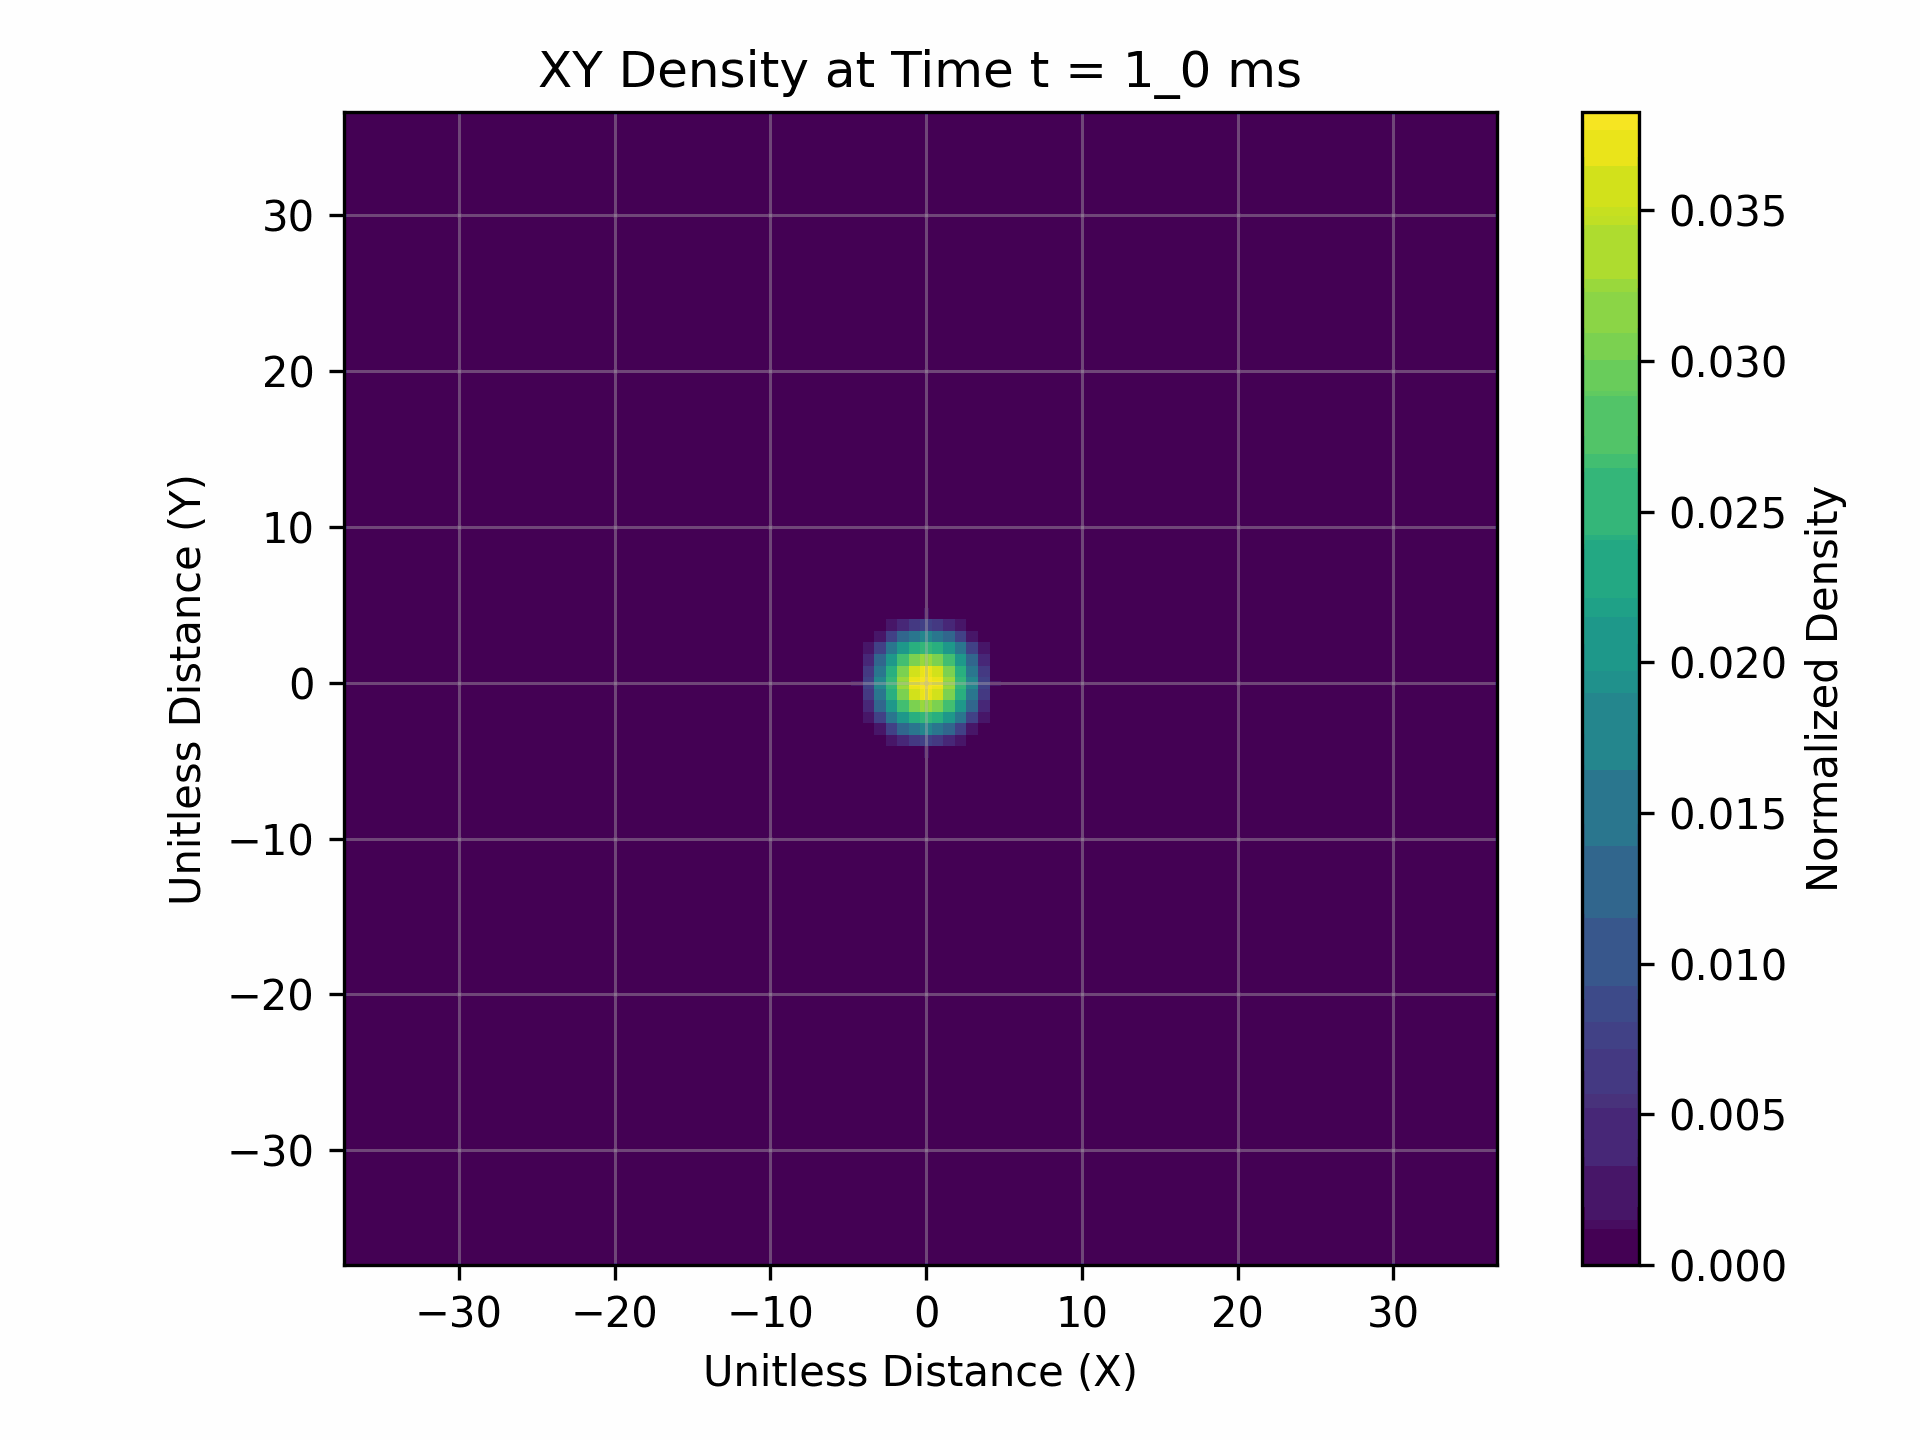

  Stitching 10 frames in 'Y_Slice'...
  -> Success! Saved Y_Slice.gif
  Stitching 10 frames in 'XY_and_Initial_Density'...
  -> Success! Saved XY_and_Initial_Density.gif
  Stitching 10 frames in 'XZ_Density'...
  -> Success! Saved XZ_Density.gif


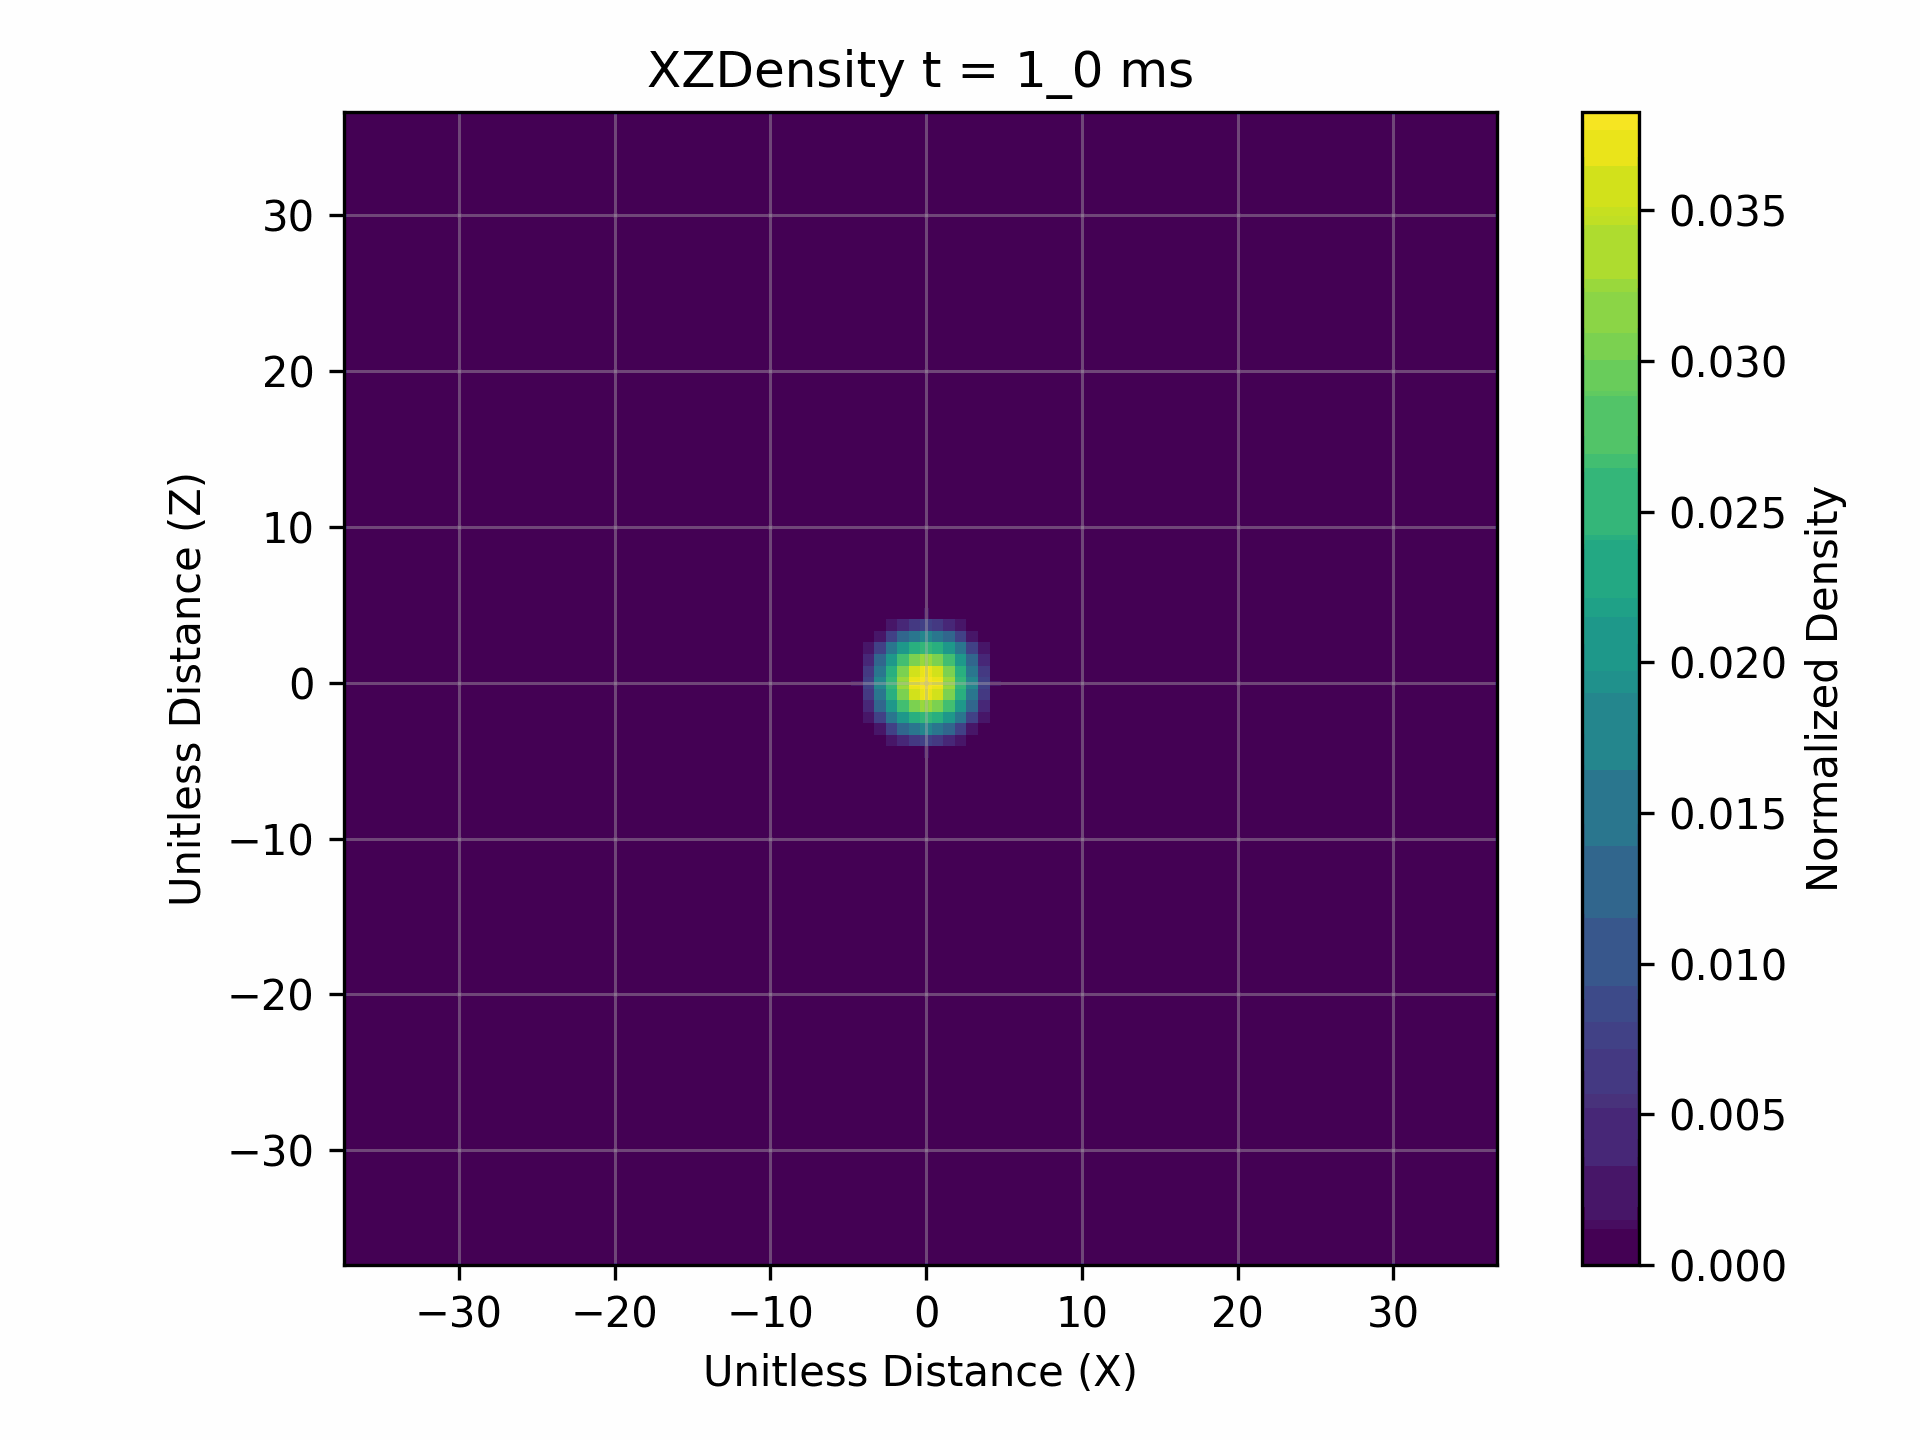

GIF generation complete.
Compressing 'storage/simulation_data_20260727_222102' into storage/simulation_data_20260727_222102_exported.zip...
Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Success! Copied to Google Drive at: /content/drive/MyDrive/Duke/SimulationData/simulation_data_20260727_222102_exported.zip
Triggering local download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
sim.export_plots()

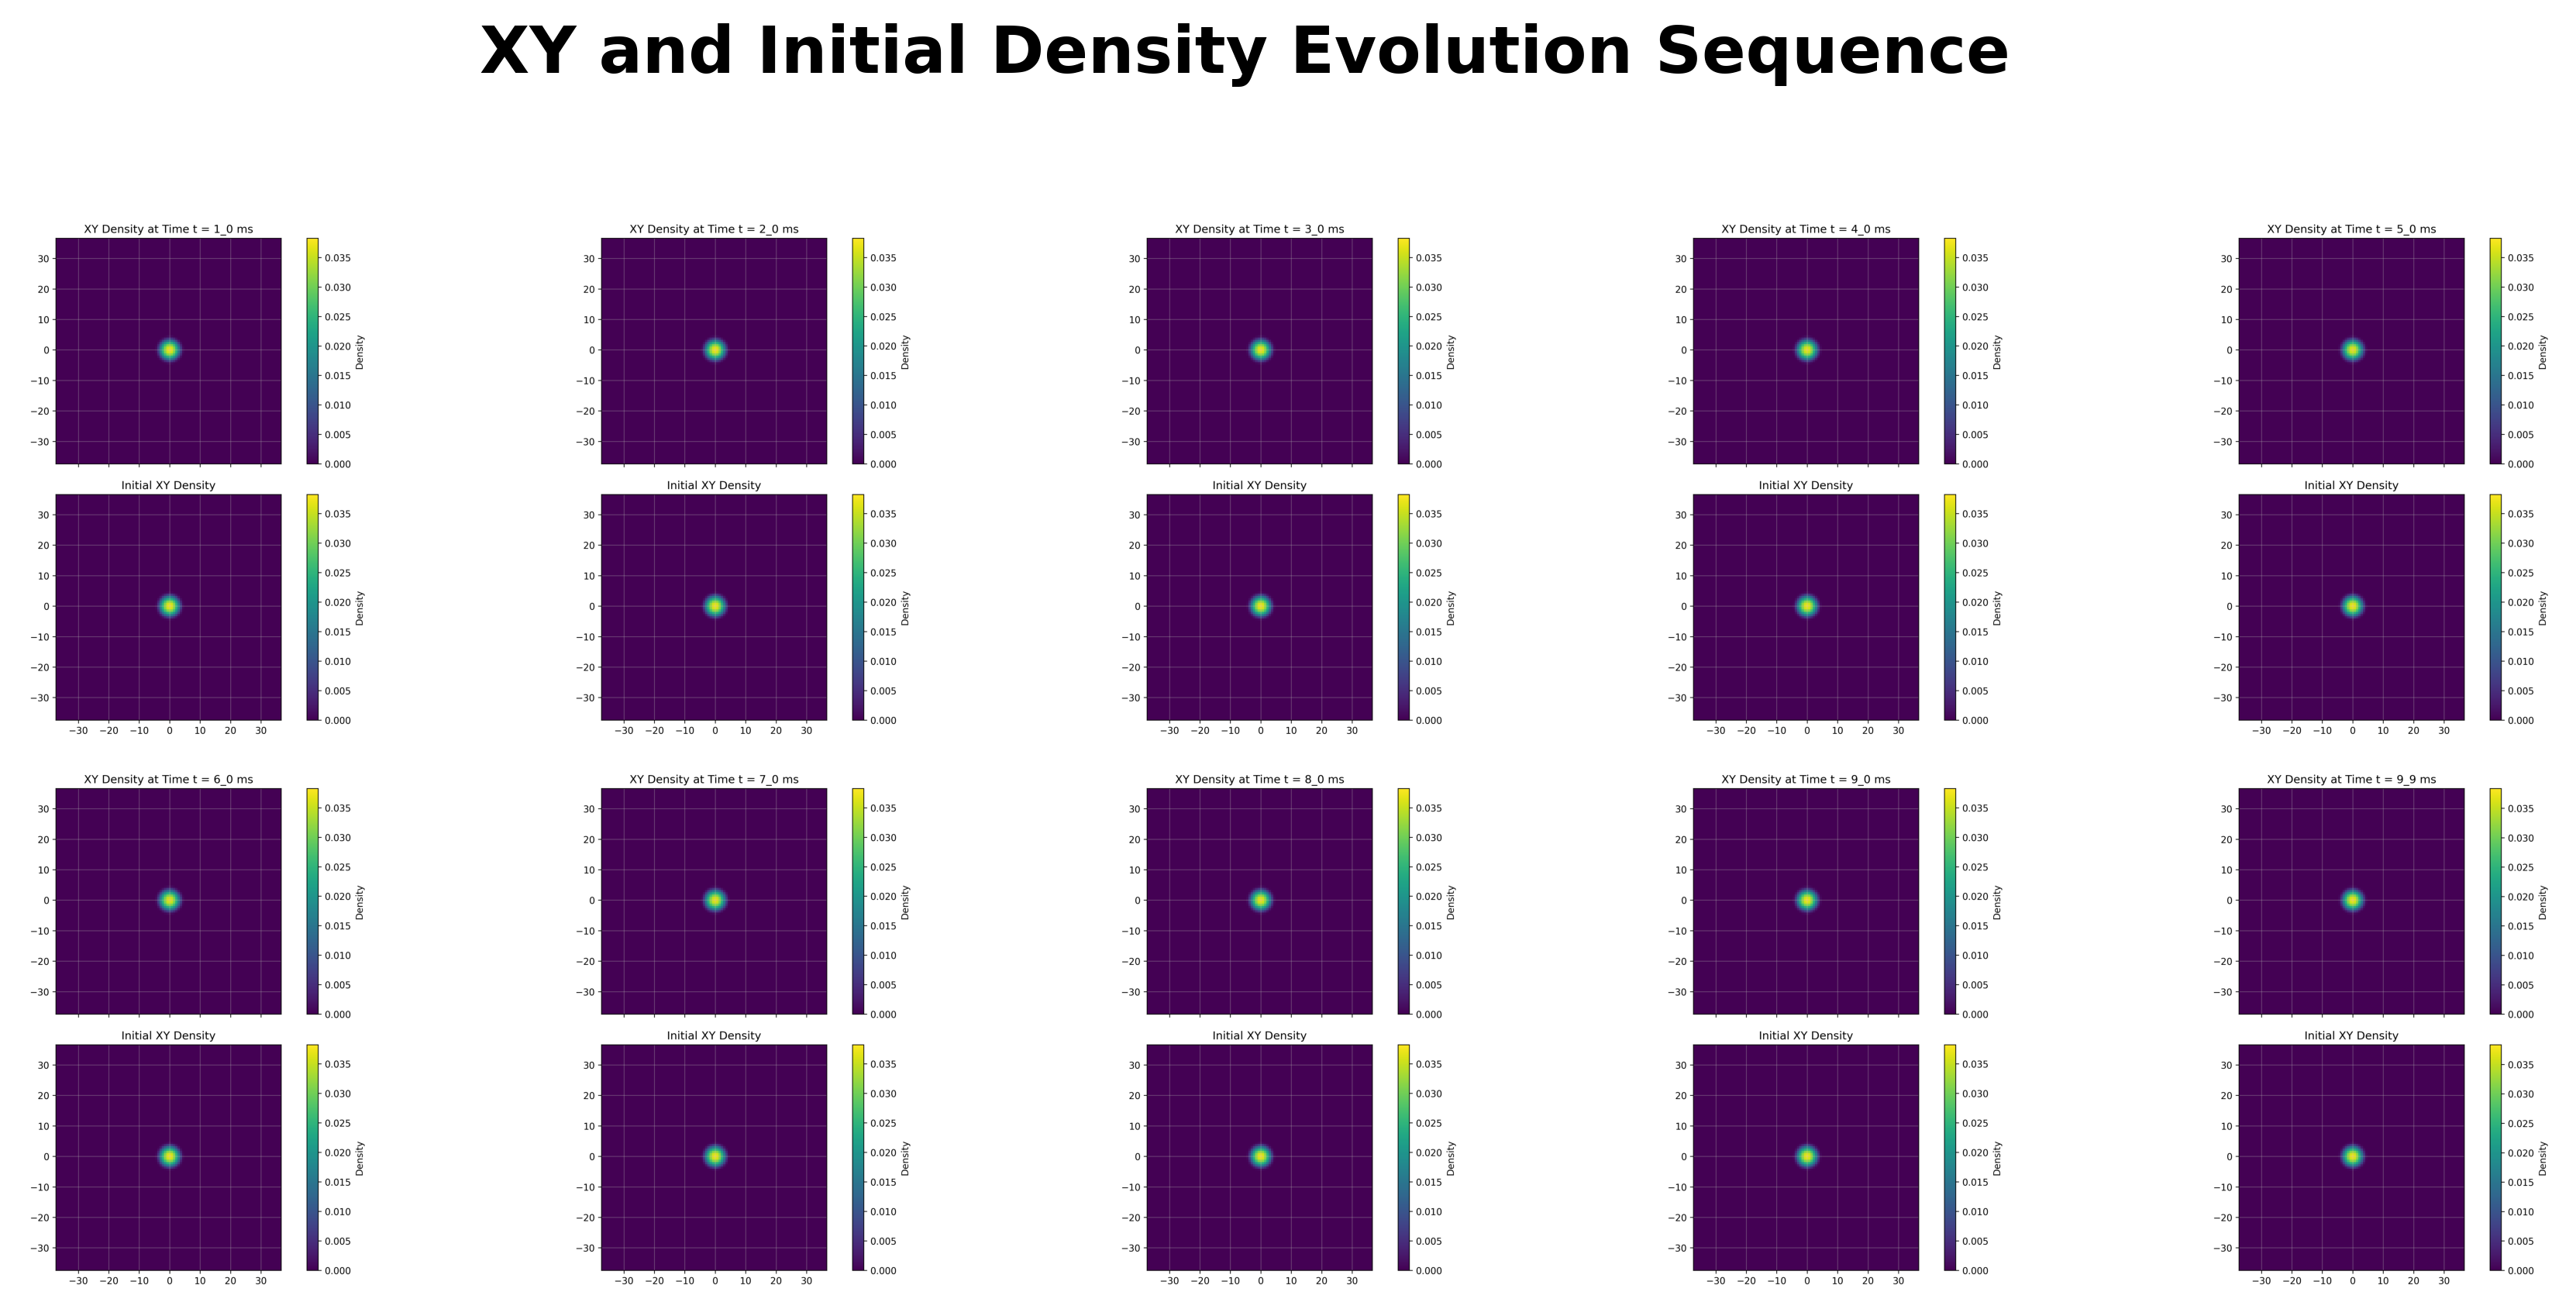

In [33]:
sim.gpe.visualizer.show_plots("Init and XY", False)

In [18]:
!ls storage/simulation_data_20260727_215046/"XY Density"

 XY_Density_0010.png   XY_Density_0050.png   XY_Density_0090.png
 XY_Density_0020.png   XY_Density_0060.png   XY_Density_0099.png
 XY_Density_0030.png   XY_Density_0070.png  'XY Density.gif'
 XY_Density_0040.png   XY_Density_0080.png


In [61]:
!rm storage/simulation_data_20260727_162744

rm: cannot remove 'storage/simulation_data_20260727_162744': Is a directory


In [46]:
sim = GPE(Np=1e5, m = 1.9e-25,
omega = 2 * pi * 40,
a0 = 2e-9,
gamma = 2,
a02 = 0,
sigma = 11e-6,
N=100,
ev_time = 0.01, #s
time_steps = 100,
cutoff="Hard Cutoff", init_type="Ground State")
sim.evolution()

Finding ground state via imaginary time...
Ground state not found. Running imaginary time evolution...
-- Simulation Parameters --
Number of particles: 100000.0
Mass (kg): 1.9e-25
Trap frequency (Hz): 251.32741228718345
Gamma:  2
Scattering length a0 (m): 2e-09
Scattering length a02 (m^3): 0
g2/g0: 0.0
Evolution time (s): 0.01
Time steps:  100
dt:  0.0001
dtau = dt/tau:  0.025132741228718346
Unitless Time (time/tau):  2.5132741228718345
Number of 1D grid points:  100
dx: 1.1000010999850929e-06
dz:  1.1000010999850929e-06
Healing length (m): 670.2780802673361
dx/healing length: 1.6411115511137772e-09
dz/healing length: 1.6411115511137772e-09
up/healing length:  8.205549550130537e-08
cutoff coeff: 0.3333333333333333
Cutoff Type:  Hard Cutoff
K_Max:  4.159337520599365
Particle Density:  44.28127431310713
na0^3:  3.542501945048571e-25
Psi initial normalization: 0.9999998211860657
Starting: 0% done
Converged at step 600 with chemical potential 7.258912
Total time: 0.5062045272166719 min
Fin

tensor([[[ 6.8865e-10-3.5096e-10j, -1.9459e-09+1.0882e-09j,
           3.0978e-10-4.2526e-10j,  ...,
          -1.3745e-09-2.8053e-09j, -8.3461e-11-5.4164e-10j,
          -2.1693e-09+2.1354e-10j],
         [-9.5057e-10-7.2510e-10j,  1.5535e-09+4.3525e-10j,
           1.2672e-09+1.2481e-09j,  ...,
          -7.4489e-11-2.2379e-09j,  9.2933e-10+1.0748e-10j,
           1.4085e-09+1.9440e-09j],
         [ 2.5166e-09+2.3626e-09j,  2.6963e-09+6.6573e-10j,
          -5.1344e-11-9.9266e-10j,  ...,
          -2.5352e-10-1.9247e-09j,  1.2912e-09-1.5289e-09j,
           1.2431e-09+3.1267e-10j],
         ...,
         [-2.0808e-09-4.1003e-10j, -4.1400e-10-5.1587e-10j,
           1.9646e-09+7.4969e-10j,  ...,
          -3.3803e-10-9.1381e-10j,  2.2010e-10+1.5447e-09j,
           6.6378e-10+1.0076e-09j],
         [ 3.8319e-09+2.2878e-09j, -9.0049e-10+6.3448e-10j,
           2.3464e-10+1.1054e-09j,  ...,
          -2.2384e-09-5.5498e-10j,  2.8056e-10+1.4500e-10j,
           2.2033e-09+2.4130e-09j],
 

In [49]:
!ls storage/simulation_data_*/"Summary Plots"

'Energy Contributions.png'  'Initial XZ Density.png'
'Initial XY Density.png'    'Initial YZ Density.png'


In [ ]:
sim = GPE(Np=1e5, m = 1.9e-25,
omega = 2 * pi * 40,
a0 = 2e-9,
gamma = 2,
a02 = 0,
sigma = 11e-6,
N=400,Nz = 400,
ev_time = 0.01, #s
time_steps = 10000,
cutoff="Hard Cutoff")
sim.evolution()

-- Simulation Parameters --
Number of particles: 100000.0
Mass (kg): 1.9e-25
Trap frequency (Hz): 251.32741228718345
Gamma:  2
Scattering length a0 (m): 2e-09
Scattering length a02 (m^3): 0
g2/g0: 0.0
Evolution time (s): 0.01
Time steps:  10000
dt:  1e-06
dtau = dt/tau:  0.0002513274122871834
Unitless Time (time/tau):  2.5132741228718345
Number of 1D grid points:  400
dx: 2.749984560068697e-07
dz:  2.749984560068697e-07
Healing length (m): 1.2142628121856156e-06
dx/healing length: 0.2264735881286568
dz/healing length: 0.2264735881286568
up/healing length:  45.29497193527865
cutoff coeff: 0.3333333333333333
Cutoff Type:  Hard Cutoff
K_Max:  16.89211654663086
Particle Density:  1.3492883030016e+19
na0^3:  1.0794306424012803e-07
Psi initial normalization: 1.0
Starting: 0% done


W0612 03:16:57.344000 1026 torch/_dynamo/variables/tensor.py:1379] [0/0] Graph break from `Tensor.item()`, consider setting:
W0612 03:16:57.344000 1026 torch/_dynamo/variables/tensor.py:1379] [0/0]     torch._dynamo.config.capture_scalar_outputs = True
W0612 03:16:57.344000 1026 torch/_dynamo/variables/tensor.py:1379] [0/0] or:
W0612 03:16:57.344000 1026 torch/_dynamo/variables/tensor.py:1379] [0/0]     env TORCHDYNAMO_CAPTURE_SCALAR_OUTPUTS=1
W0612 03:16:57.344000 1026 torch/_dynamo/variables/tensor.py:1379] [0/0] to include these operations in the captured graph.
W0612 03:16:57.344000 1026 torch/_dynamo/variables/tensor.py:1379] [0/0] 
W0612 03:16:57.344000 1026 torch/_dynamo/variables/tensor.py:1379] [0/0] Graph break: from user code at:
W0612 03:16:57.344000 1026 torch/_dynamo/variables/tensor.py:1379] [0/0]   File "/tmp/ipykernel_1026/3957563941.py", line 758, in single_loop
W0612 03:16:57.344000 1026 torch/_dynamo/variables/tensor.py:1379] [0/0]     self.energy = (KE_energy.item(

Roughly 10.0% done
Elapsed time: 3.04 minutes
Roughly 20.0% done
Elapsed time: 2.62 minutes
Roughly 30.0% done
Elapsed time: 2.62 minutes
Roughly 40.0% done
Elapsed time: 2.62 minutes
Roughly 50.0% done
Elapsed time: 2.62 minutes
Roughly 60.0% done
Elapsed time: 2.63 minutes
Roughly 70.0% done
Elapsed time: 2.63 minutes
Roughly 80.0% done
Elapsed time: 2.62 minutes
Roughly 90.0% done
Elapsed time: 2.62 minutes
Roughly 99.99% done
Elapsed time: 2.62 minutes
Total time: 26.73059298101667 min
Final WF normalization 1.0011138916015625


array([[[-8.94381547e-09+1.07875542e-09j,
         -4.52213067e-09-1.56496291e-08j,
          6.48087806e-10-3.76047193e-09j, ...,
          1.33021585e-08-7.46099404e-10j,
          1.43072736e-08-1.20073613e-08j,
          4.02364542e-09-1.75807529e-08j],
        [-1.01345676e-09+3.32225514e-09j,
         -2.65745342e-10-8.15518408e-09j,
          2.49031573e-09-1.09155718e-09j, ...,
          1.38416896e-08+9.32659194e-09j,
          7.92194488e-09-9.11368225e-09j,
         -8.75529260e-10-1.42655354e-08j],
        [-4.68976102e-09+1.05749862e-08j,
         -1.02546913e-08-1.40632848e-08j,
          9.54918722e-09-4.97248109e-09j, ...,
          5.58092816e-09-8.19608648e-09j,
          4.89485696e-09-7.34360184e-10j,
         -1.89731719e-09-1.80018711e-09j],
        ...,
        [-9.54052926e-09+2.23810814e-09j,
          1.23087709e-08-7.34071692e-09j,
          3.82819637e-10-1.01950870e-09j, ...,
          1.63462648e-08+1.43723620e-08j,
          5.66814506e-09-3.27497029e-09j